In [187]:
import numpy as np
import os
from matplotlib import pyplot as plt


In [206]:
path = "outputs/NON-IID/"
npz_files = [path + f for f in os.listdir(path)]
npz_files_sorted = sorted(npz_files, key=os.path.getctime)
res = []
for e, i in enumerate(npz_files_sorted):
    if "FedCrypt.npz" in i:
        print(i)
        res.append(i)

outputs/NON-IID/FHE_1750881746.8718762_ConvMixer_CIFAR100_FedCrypt.npz
outputs/NON-IID/FHE_1750875762.06554_VGG_CIFAR10_FedCrypt.npz
outputs/NON-IID/FHE_1750869247.314138_ResNet_MNIST_FedCrypt.npz


In [216]:
i = 0
print(np.load(res[i])["arr_0"][-20], np.load(res[i])["arr_1"][-1])

0.5515 0.1


In [180]:
final_res = []
for i in res:
    a = np.load(i)
    final_res.append(a["arr_0"][:,0])
final_res = np.array(final_res)

In [181]:
acc = final_res

In [182]:
final_res = []
for i in res:
    a = np.load(i)
    final_res.append(a["arr_1"][:,0])
final_res = np.array(final_res)

In [183]:
wsr = final_res

In [179]:
acc = np.load(res[2])["arr_0"]
wsr = np.load(res[2])["arr_1"]

In [184]:
print(acc,wsr)

[[0.8786 0.8797 0.8788 0.8788 0.869  0.8517 0.7821 0.6396 0.2485 0.1
  0.1   ]
 [0.8772 0.8767 0.8774 0.8767 0.8715 0.8601 0.8166 0.6266 0.1466 0.1
  0.1   ]
 [0.878  0.877  0.8754 0.8756 0.8682 0.8476 0.7912 0.6041 0.1173 0.1
  0.1   ]] [[1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  0.5]
 [1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  0.5]
 [1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  0.5]]


In [6]:
test_accuracy = acc.transpose()[0]
wdr_dynamic = wsr.transpose()[0]
pruning_rates = np.arange(0,1.1,0.1)

In [185]:
wdr_std

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [186]:
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans"],  # ou "Helvetica", selon ce que tu veux
})

pruning_rates = np.arange(0,1.1,0.1)

test_accuracy = acc
wdr_dynamic = wsr

accuracy_mean = np.mean(test_accuracy, axis=0)
accuracy_std = np.std(test_accuracy, axis=0)

wdr_mean =  np.mean(wdr_dynamic, axis=0)
wdr_std = np.std(wdr_dynamic, axis=0)

plt.figure(figsize=(4, 3), dpi=400)
plt.axes(facecolor="#f7f7f7")

plt.plot(pruning_rates, accuracy_mean, c="blue", label="Test Acc.")
plt.fill_between(
    pruning_rates,
    accuracy_mean - accuracy_std,
    accuracy_mean + accuracy_std,
    color="blue",
    alpha=0.25,
)

plt.plot(pruning_rates, wdr_mean, c="green", label="WSR")
plt.fill_between(
    pruning_rates, wdr_mean - wdr_std, wdr_mean + wdr_std, color="green", alpha=0.25
)

plt.plot(
    pruning_rates,
    0.7 * np.ones(len(pruning_rates)),
    c="black",
    label="Threshold",
    linestyle="dashed",
)

plt.xlabel("Pruning rate")
plt.xlim(0, 1)
plt.ylim(0 - 0.1, 1 + 0.1)
plt.xticks(np.arange(0, 1.01, 0.2))
plt.yticks(np.arange(0, 1.01, 0.2))
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(path + "fedtracker_pruning.pdf")
plt.close()

In [55]:
pruning_rates.shape

(11,)

In [54]:
wdr_dynamic.shape

(11,)

In [101]:
path = "outputs/"
npz_files = [path + f for f in os.listdir(path)]
npz_files_sorted = sorted(npz_files, key=os.path.getctime)
res = []
for e, i in enumerate(npz_files_sorted):
    if "overwriting" in i:
        print(i)
        res.append(i)

outputs/fedtracker_overwriting.pdf
outputs/fedipr_overwriting.pdf
outputs/overwriting_<built-in function id>.pth.npz
outputs/overwriting_ResNet_80_5_FHE_1750406135.0600848_ResNet_MNIST_FedIPR.npz
outputs/overwriting_ResNet_80_5_FHE_1750407864.2315993_ResNet_MNIST_FedTracker.npz


In [106]:
i = 4
acc = np.load(res[i])["arr_0"]#[1:]
wsr_org = np.load(res[i])["arr_1"]#[1:]
wsr_atk = np.load(res[i])["arr_2"]#[1:]

In [107]:
print(acc[-1], wsr_org[-1], wsr_atk[-1])

0.9848 0.55859375 1.0


In [53]:
acc = acc[::10]
wsr_org = wsr_org[::10]
wsr_atk = wsr_atk[::10]

ValueError: x and y must have same first dimension, but have shapes (11,) and (3, 11)

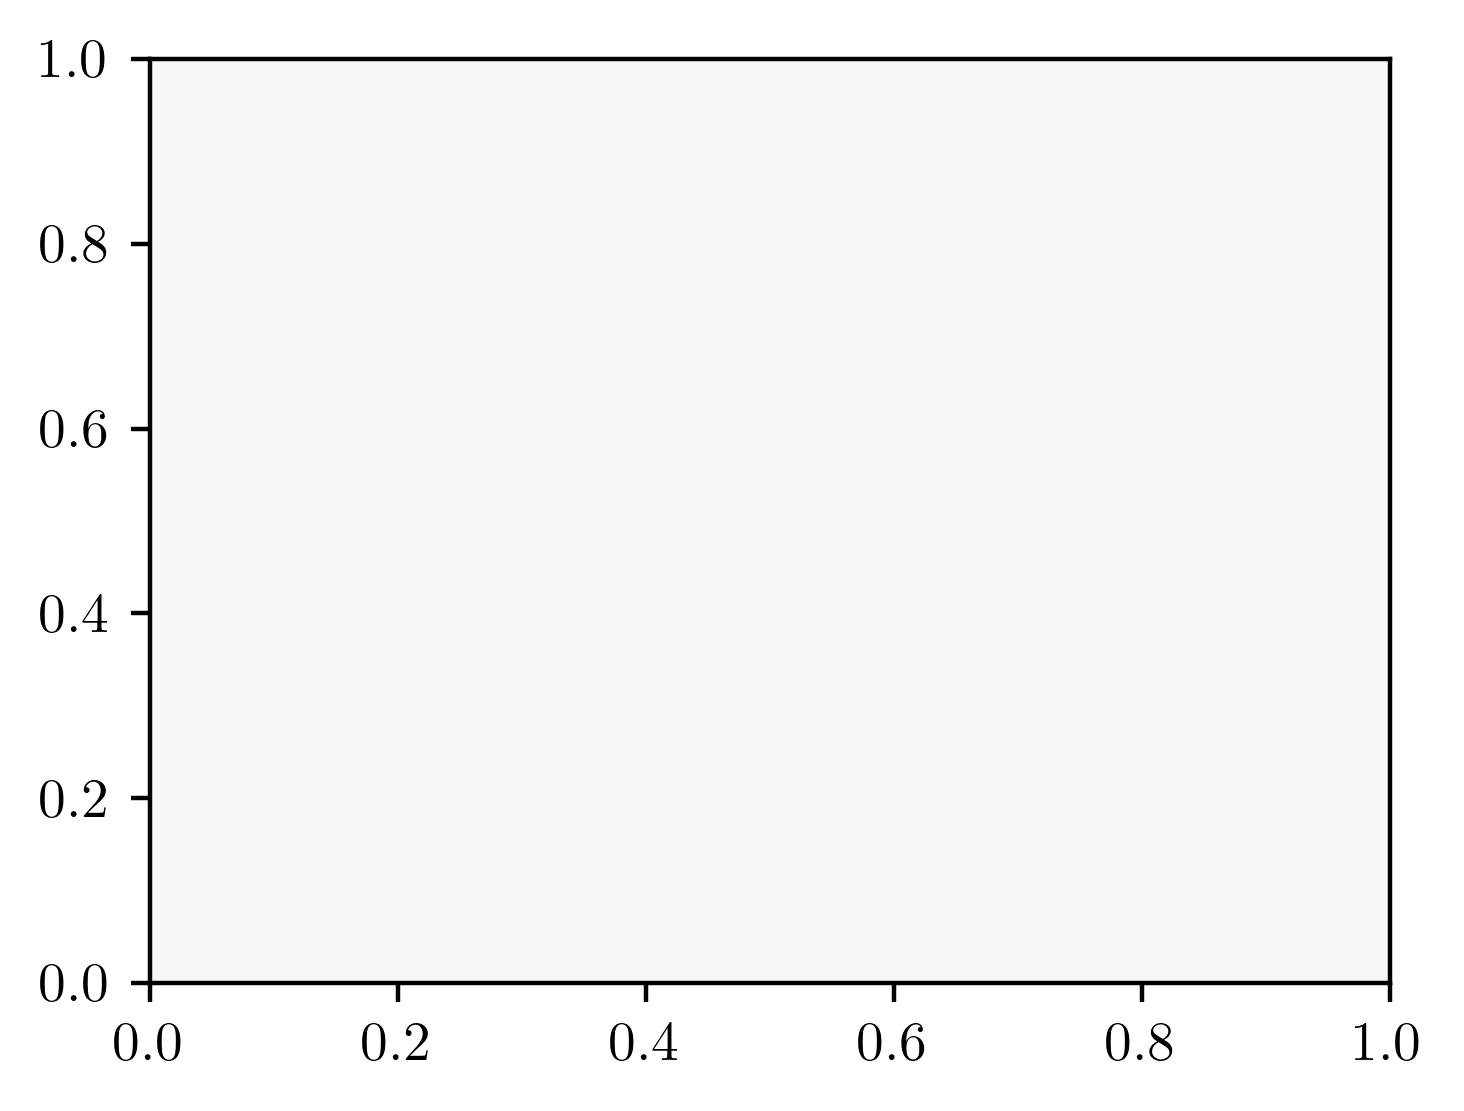

In [144]:
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans"],  # ou "Helvetica", selon ce que tu veux
})
accuracy_mean = acc # np.mean(acc_test, axis=0)
accuracy_std = acc # np.std(acc_test, axis=0)

wdr_org_mean = wsr_org # np.mean(wdr_org, axis=0)
wdr_org_std = wsr_org # np.std(wdr_org, axis=0)

wdr_new_mean = wsr_atk # np.mean(wdr_new, axis=0)
wdr_new_std = wsr_atk # np.std(wdr_new, axis=0)
# %%
fig = plt.figure(figsize=(4, 3), dpi=400)
plt.axes(facecolor="#f7f7f7")
epoch = np.arange(0, 101 , 10)
plt.plot(epoch, accuracy_mean, c="blue", label="Test Acc.")
plt.fill_between(
    epoch,
    accuracy_mean - accuracy_std,
    accuracy_mean + accuracy_std,
    color="blue",
    alpha=0.25,
)

plt.plot(epoch, wdr_org_mean, c="green", label=r"$\mathcal{O}$'s WSR", markersize=5)
plt.fill_between(
    epoch,
    wdr_org_mean - wdr_org_std,
    wdr_org_mean + wdr_org_std,
    color="green",
    alpha=0.25,
)

plt.plot(epoch, wdr_new_mean, c="red", label=r"$\mathcal{A}$'s WSR", markersize=5)
plt.fill_between(
    epoch,
    wdr_new_mean - wdr_new_std,
    wdr_new_mean + wdr_new_std,
    color="red",
    alpha=0.25,
)

plt.plot(
    epoch,
    0.7 * np.ones(len(epoch)),
    c="black",
    label="Treshold",
    linestyle="dashed",
)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.xlim(0, epoch[-1])
plt.ylim(0, 1)
plt.xticks(np.arange(0, epoch[-1] + 1, 10))
plt.yticks(np.arange(0, 1.01, 0.2))
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(path + "fedipr_overwriting.pdf")
plt.close()


In [7]:
wsr_atk.shape

(7,)

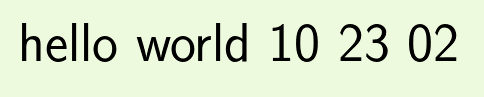

In [26]:
def print_text(text):
    fig, ax = plt.subplots(figsize=(6, 1), facecolor="#eefade")
    ax.text(0.5, 0.5, text, ha='center', va='center', size=40)
    ax.axis("off")
    plt.show()
print_text("hello world 10 23 02")